In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn import metrics
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

In [56]:
df=pd.read_csv('/content/bitcoin.csv')
df.sample()

,Date,Open,High,Low,Close,Adj Close,Volume
1374,2018-06-22,6737.879883,6747.080078,6006.600098,6083.689941,6083.689941,5079810048


In [57]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [58]:
df.shape

(2713, 7)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


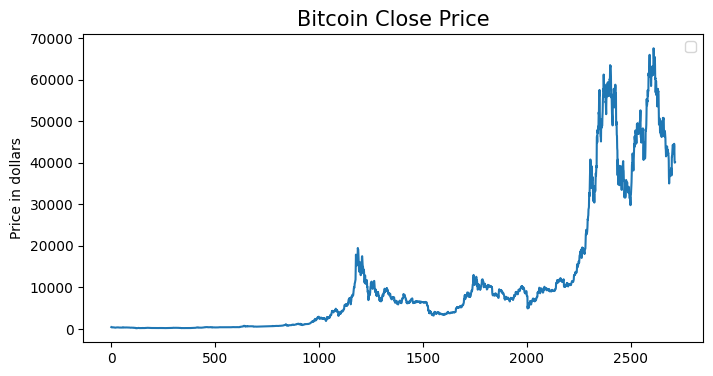

In [60]:
plt.figure(figsize=(8,4))
plt.plot(df['Close'])
plt.title('Bitcoin Close Price',fontsize=15)
plt.ylabel("Price in dollars")
plt.legend()
plt.show()

In [61]:
df=df.drop(['Adj Close'],axis=1)

In [62]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


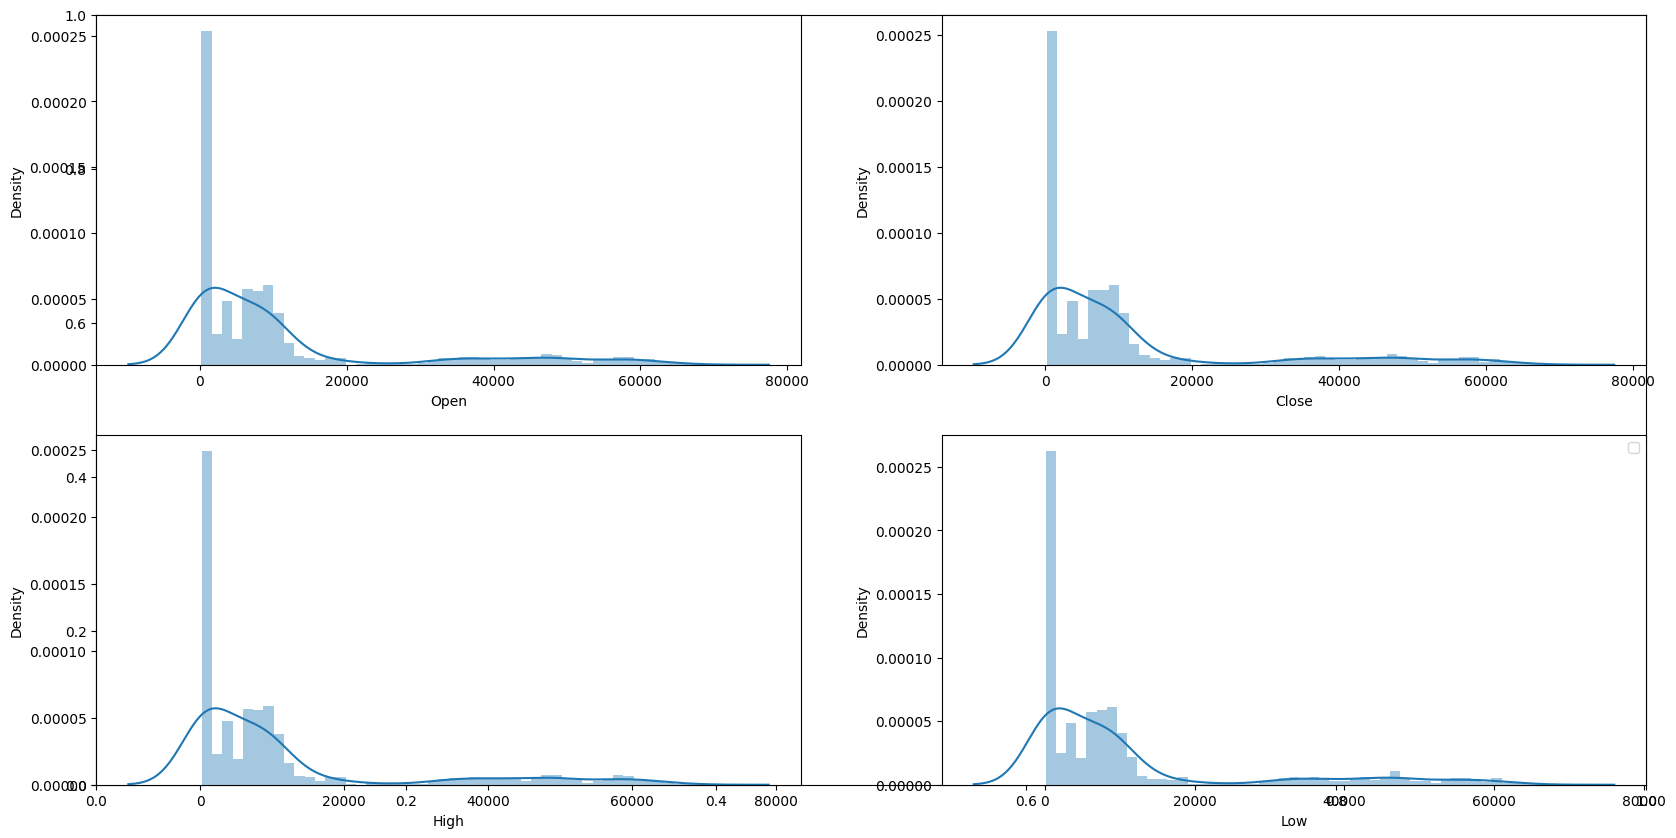

In [63]:
features=['Open','Close','High','Low']
plt.subplots(figsize=(20,10))
for i,col in enumerate(features):
  plt.subplot(2,2,i+1)
  sns.distplot(df[col])
plt.legend()
plt.show()

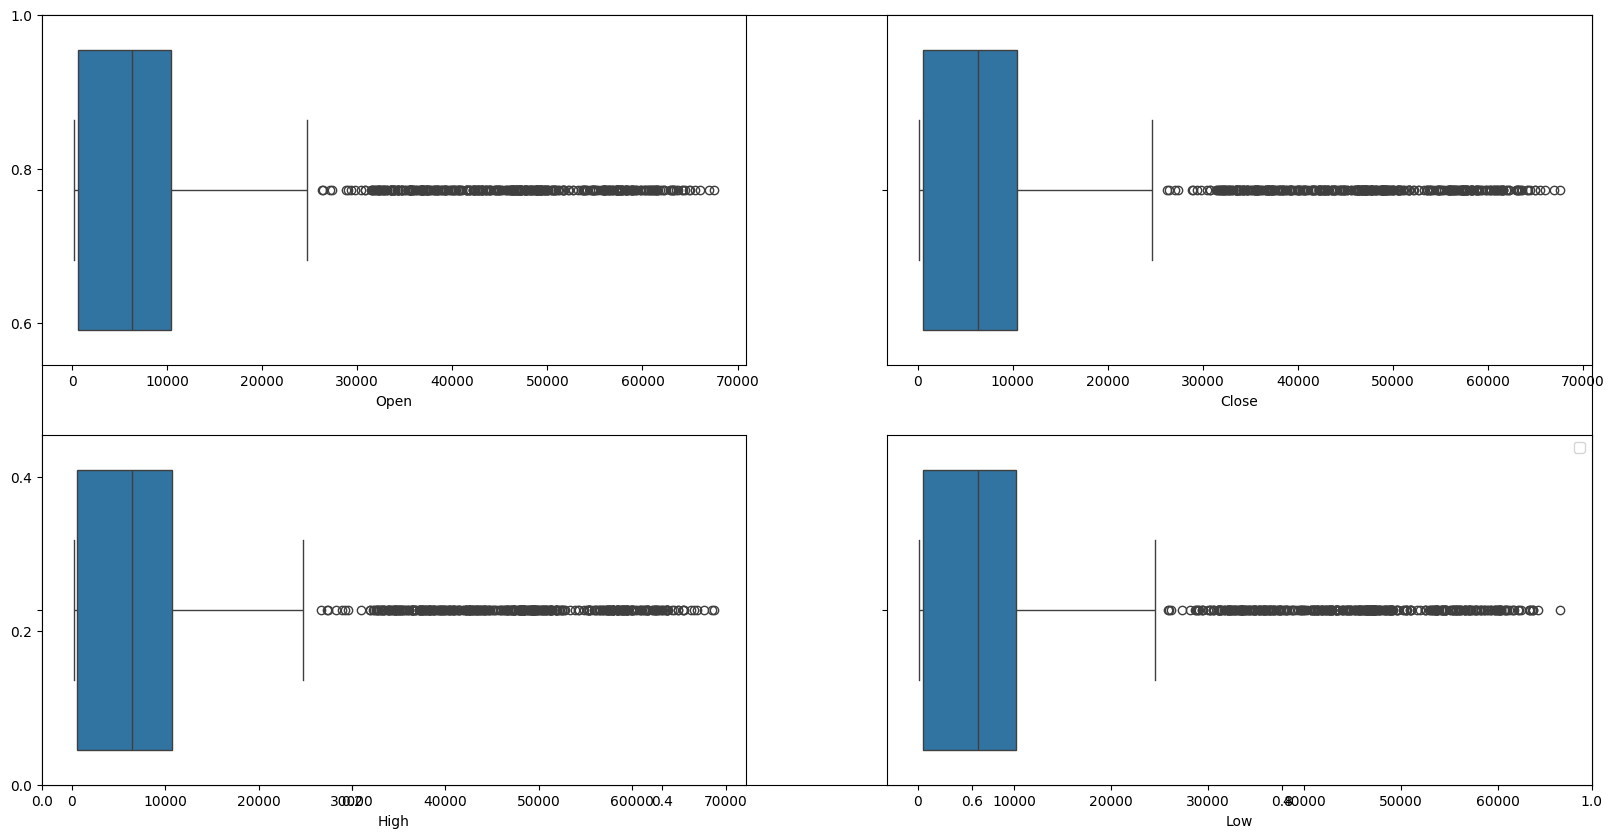

In [64]:
plt.subplots(figsize=(20,10))
for i,col in enumerate(features):
  plt.subplot(2,2,i+1)
  sns.boxplot(df[col],orient='h')
plt.legend()
plt.show(
)

In [65]:
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values('Date')

In [66]:
df['Target']=(df['Close'].shift(-1)>df['Close']).astype(int)

In [67]:
df['return']=df['Close'].pct_change()
df['ma7']=df['Close'].rolling(7).mean()
df['ma21']=df['Close'].rolling(21).mean()
df['volatility']=df['Close'].rolling(7).std()

In [69]:
df=df.dropna(
)

In [71]:
df.shape

(2693, 11)

In [72]:
split=int(len(df)*0.8)
split

2154

In [75]:
train=df[:split]
test=df[split:]
features=['return','ma7','ma21','volatility']
X_train=train[features]
X_test=test[features]
y_train=train['Target']
y_test=test['Target']

In [76]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2154, 4), (539, 4), (2154,), (539,))

In [77]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [78]:
baseline_pred=train['Target'].iloc[-1]
baseline_test=np.full(len(y_test),baseline_pred)
print("Baseline Accuracy:", metrics.accuracy_score(y_test, baseline_test))

Baseline Accuracy: 0.536178107606679


In [80]:
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f'Logistic Regression Accuracy: {metrics.accuracy_score(y_test,y_pred)}')
print(f'Logistic Regression Classification Report: {metrics.classification_report(y_test,y_pred)}')
print(f'Logistic Regression ROC-AUC: {metrics.roc_auc_score(y_test,y_pred)}')

Logistic Regression Accuracy: 0.4712430426716141
Logistic Regression Classification Report:               precision    recall  f1-score   support

           0       0.46      0.93      0.62       250
           1       0.55      0.08      0.13       289

    accuracy                           0.47       539
   macro avg       0.51      0.50      0.38       539
weighted avg       0.51      0.47      0.36       539

Logistic Regression ROC-AUC: 0.5020622837370242


In [82]:
xgb=XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
print(f'XGBClassifier Accuracy: {metrics.accuracy_score(y_test,xgb_pred)}')
print(f'XGBClassifer Classification Report: {metrics.classification_report(y_test,xgb_pred)}')
print(f'XGBClassifer ROC-AUC: {metrics.roc_auc_score(y_test,xgb_pred)}')

XGBClassifier Accuracy: 0.4972170686456401
XGBClassifer Classification Report:               precision    recall  f1-score   support

           0       0.48      0.94      0.63       250
           1       0.69      0.11      0.20       289

    accuracy                           0.50       539
   macro avg       0.58      0.53      0.42       539
weighted avg       0.59      0.50      0.40       539

XGBClassifer ROC-AUC: 0.5270934256055363


In [84]:
print('Distribution of Target in Training Set:')
print(y_train.value_counts(normalize=True))
print('\nDistribution of Target in Test Set:')
print(y_test.value_counts(normalize=True))

Distribution of Target in Training Set:
Target
1    0.545032
0    0.454968
Name: proportion, dtype: float64

Distribution of Target in Test Set:
Target
1    0.536178
0    0.463822
Name: proportion, dtype: float64


In [85]:
df['ema7'] = df['Close'].ewm(span=7, adjust=False).mean()
df['ema21'] = df['Close'].ewm(span=21, adjust=False).mean()

# RSI Calculation
delta = df['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()

rs = avg_gain / avg_loss
df['rsi'] = 100 - (100 / (1 + rs))

# MACD Calculation
df['ema12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['ema26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['macd'] = df['ema12'] - df['ema26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

df = df.dropna()

print("New technical indicators added and NaN values dropped.")
df.head()

New technical indicators added and NaN values dropped.


,Date,Open,High,Low,Close,Volume,Target,return,ma7,ma21,volatility,ema7,ema21,rsi,ema12,ema26,macd,macd_signal
21,2014-10-08,336.115997,354.364014,327.187988,352.940002,54736300,1,0.049832,343.309431,382.380999,19.656765,340.375259,337.710011,100.000000,338.764395,337.427974,1.336421,0.267284
22,2014-10-09,352.747986,382.726013,347.687012,365.026001,83641104,0,0.034244,341.874289,379.551761,17.159362,346.537945,340.193283,100.000000,342.804642,339.472273,3.332370,0.880301
23,2014-10-10,364.687012,375.066986,352.963013,361.562012,43665700,1,-0.009490,342.167149,377.969190,17.524172,350.293962,342.135895,86.939126,345.690391,341.108550,4.581842,1.620609
24,2014-10-11,361.362000,367.191010,355.950989,362.299011,13345200,1,0.002038,346.943294,375.749905,17.847829,353.295224,343.968905,87.344893,348.245564,342.678213,5.567350,2.409958
25,2014-10-12,362.605988,379.433014,356.144012,378.549011,17552800,1,0.044852,355.234580,374.784572,16.981631,359.608671,347.112551,92.931627,352.907632,345.335309,7.572323,3.442431


In [86]:
features = ['return', 'ma7', 'ma21', 'volatility', 'ema7', 'ema21', 'rsi', 'macd', 'macd_signal']
split = int(len(df) * 0.8)
train = df[:split]
test = df[split:]
X_train = train[features]
X_test = test[features]
y_train = train['Target']
y_test = test['Target']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print("Data re-split and features scaled successfully.")

X_train_scaled shape: (2153, 9)
X_test_scaled shape: (539, 9)
Data re-split and features scaled successfully.


In [87]:
print('--- Logistic Regression with New Features ---')
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
print(f'Logistic Regression Accuracy: {metrics.accuracy_score(y_test, y_pred_lr)}')
print(f'Logistic Regression Classification Report:\n{metrics.classification_report(y_test, y_pred_lr)}')
print(f'Logistic Regression ROC-AUC: {metrics.roc_auc_score(y_test, y_pred_lr)}')

print('\n--- XGBoost with New Features ---')
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(f'XGBClassifier Accuracy: {metrics.accuracy_score(y_test, y_pred_xgb)}')
print(f'XGBClassifer Classification Report:\n{metrics.classification_report(y_test, y_pred_xgb)}')
print(f'XGBClassifer ROC-AUC: {metrics.roc_auc_score(y_test, y_pred_xgb)}')

--- Logistic Regression with New Features ---
Logistic Regression Accuracy: 0.47866419294990725
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.91      0.62       250
           1       0.57      0.11      0.18       289

    accuracy                           0.48       539
   macro avg       0.52      0.51      0.40       539
weighted avg       0.52      0.48      0.38       539

Logistic Regression ROC-AUC: 0.5076332179930797

--- XGBoost with New Features ---
XGBClassifier Accuracy: 0.49907235621521334
XGBClassifer Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.84      0.61       250
           1       0.59      0.21      0.31       289

    accuracy                           0.50       539
   macro avg       0.54      0.52      0.46       539
weighted avg       0.54      0.50      0.45       539

XGBClassifer ROC-AUC: 0.5218062283737024
